In [2]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

In [3]:
load_dotenv()

True

In [4]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [5]:
class summarystate(MessagesState):
    summary: str

In [6]:
def chat_node(state: summarystate):
    messages = []
    
    # we will check for the messages in state
    if state['messages']:
        messages.append({
            "role" : "system",
            "content" : f"Conversation Summary {state['messages']}"
        })
        
    # then we will attach this in the state
    messages.extend(state["messages"])
    
    print(messages)
    
    response = LLM.invoke(messages)
    return {"messages" : [response]}

In [7]:
# now building our summarizer node
def summarry_node(state: summarystate):
    
    # getting the summary from the state
    existing_summary = state['summary']
    
    #building the prompt 
    if existing_summary:
        prompt = (f"existing summary\n {state['summary']}"
        "extend the summary using the new conversation above")
    else:
        prompt = "Summarize the above conversation"
        
    # combining both 
    message_for_summary = state['summary'] + [HumanMessage(content=prompt)] 
    
    # giving this message to llm(summary generation)
    response = LLM.invoke(message_for_summary)
    
    # performing deletion for the rest and keeping just 2
    message_for_deletion = state['messages'][:-2]
    
    # now returining 2 things 
    return {
        "Summary" : response.content,
        "Messages" : [RemoveMessage(id=m.id) for m in message_for_deletion]
    }

In [8]:
def should_summarize(state: summarystate):
    return len(state['messages'])>6

In [9]:
#building the node
graph = StateGraph(summarystate)

graph.add_node("chat_node", chat_node)
graph.add_node("summarry_node", summarry_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_summarize,{True: "summarry_node", False: "__end__"})
graph.add_edge("summarry_node", END)


In [10]:
#implementing checkpointer
memory = InMemorySaver()
STM_summarize = graph.compile(checkpointer=memory)


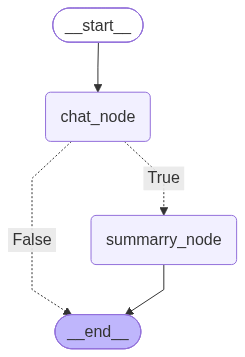

In [11]:
from IPython.display import Image
Image(STM_summarize.get_graph().draw_mermaid_png())

In [12]:
config = {"configurable": {"thread_id": "t1"}}

In [15]:
# gives the current version of the state
def show_state():
    snap = STM_summarize.get_state(config)
    vals = snap.values

    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")

    for m in vals.get("messages", []):
        print(" -", type(m).__name__, ":", m.content[:80])

In [16]:
out = STM_summarize.invoke({"messages": [HumanMessage(content="quantum Physics")], 'summary' : ""}, config=config)
print(out)
show_state()

[{'role': 'system', 'content': 'Conversation Summary [HumanMessage(content=\'quantum Physics\', additional_kwargs={}, response_metadata={}, id=\'19dabf94-eaea-40a7-88fd-ff9c9f1dd4a9\'), AIMessage(content=\'Sure! Here’s a quick, high‑level overview of quantum physics (also called quantum mechanics), the branch of physics that describes how the universe works at the smallest scales—atoms, electrons, photons, and other elementary particles.\\n\\n---\\n\\n## 1. Why Classical Physics Fails\\n\\n- **Classical mechanics** (Newton’s laws) and **electromagnetism** (Maxwell’s equations) work extremely well for everyday objects and for many macroscopic phenomena.\\n- When scientists probed **atomic and sub‑atomic scales** (e.g., black‑body radiation, the photoelectric effect, atomic spectra), the predictions of classical physics were wildly off.\\n- In the early 20th\\u202fcentury, a new set of rules—**quantum mechanics**—was developed to explain these anomalies.\\n\\n---\\n\\n## 2. Core Principl